<h1>ABIOLA PEACE EMMANUEL</h1>
<h2>MODULE : APPLIED ARTIFICIAL INTELLIGENCE</h2>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


<h1>Loading and Creating Binary Labels</h1>

In [7]:
df = pd.read_csv("train.csv")

# Create binary label: 1 if any toxic-type label is 1, else 0
toxic_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
df['toxic_binary'] = (df[toxic_cols].sum(axis=1) > 0).astype(int)

df = df[['comment_text', 'toxic_binary']]

df.head()


,comment_text,toxic_binary
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


<h1>✅STEP 1 — Class Distribution Plot</h1>

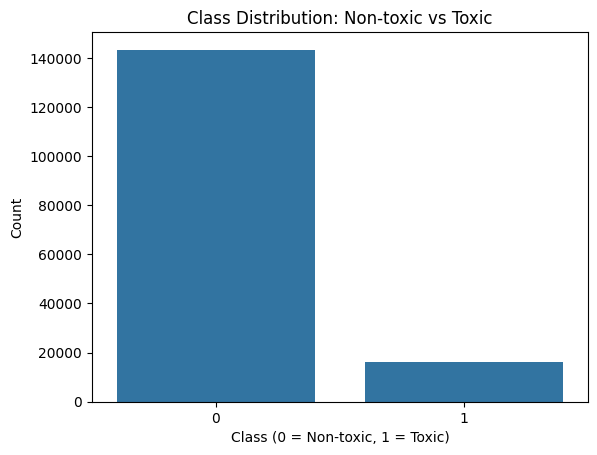

In [12]:
sns.countplot(data=df, x='toxic_binary')
plt.title("Class Distribution: Non-toxic vs Toxic")
plt.xlabel("Class (0 = Non-toxic, 1 = Toxic)")
plt.ylabel("Count")
plt.show()


<h1>✅ STEP 2 — Comment Length Distribution</h1>

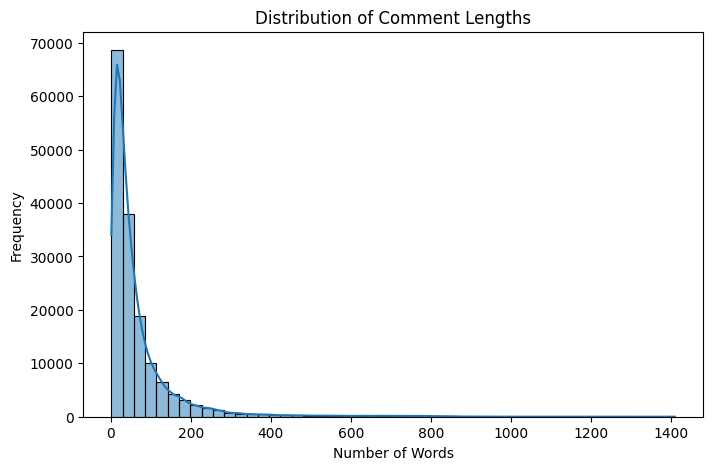

In [13]:
df['text_length'] = df['comment_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], kde=True, bins=50)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


<h1>Wordcloud</h1>

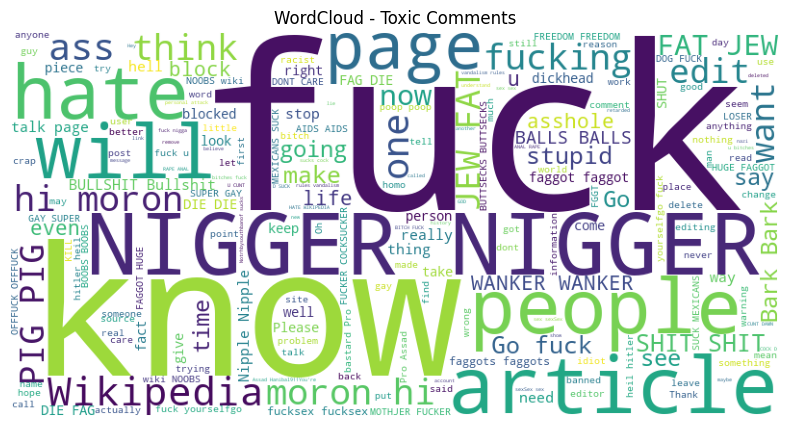

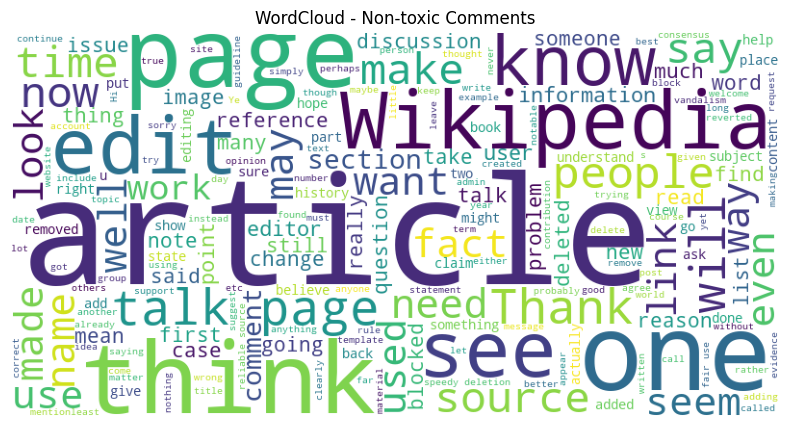

In [14]:
from wordcloud import WordCloud

toxic_text = " ".join(df[df['toxic_binary']==1]['comment_text'])
nontoxic_text = " ".join(df[df['toxic_binary']==0]['comment_text'])

wc_toxic = WordCloud(width=800, height=400, background_color='white').generate(toxic_text)
wc_nontoxic = WordCloud(width=800, height=400, background_color='white').generate(nontoxic_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_toxic)
plt.title("WordCloud - Toxic Comments")
plt.axis("off")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(wc_nontoxic)
plt.title("WordCloud - Non-toxic Comments")
plt.axis("off")
plt.show()


<h1>STEP 4 — Baseline Metric</h1>

In [15]:
majority_class = df['toxic_binary'].mode()[0]
baseline_accuracy = (df['toxic_binary'] == majority_class).mean()
baseline_accuracy


np.float64(0.8983211235124177)

<h1>✅ PHASE 1 — TRADITIONAL MODEL 1: Multinomial Naive Bayes</h1>

Naive Bayes F1: 0.6140680442496347
Naive Bayes ROC-AUC: 0.9451223878543524
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     28670
           1       0.95      0.45      0.61      3245

    accuracy                           0.94     31915
   macro avg       0.95      0.73      0.79     31915
weighted avg       0.94      0.94      0.93     31915



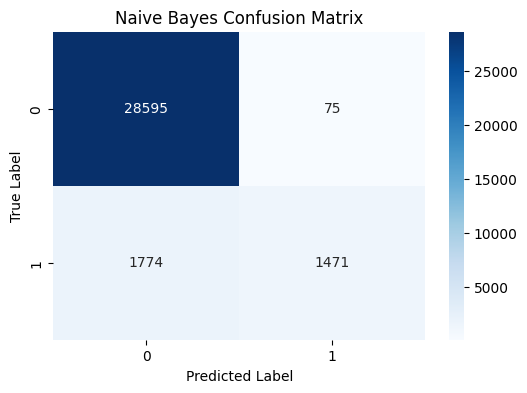

In [16]:
# ===== Naive Bayes Full Pipeline (TF–IDF + Training + Evaluation) =====
# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    df['comment_text'],
    df['toxic_binary'],
    test_size=0.2,
    random_state=42,
    stratify=df['toxic_binary']
)

# --- TF-IDF Vectorisation ---
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=30000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# --- Train Naive Bayes ---
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)

# --- Predictions ---
y_pred_nb = nb.predict(X_test_tfidf)
y_prob_nb = nb.predict_proba(X_test_tfidf)[:,1]

# --- Evaluation ---
print("Naive Bayes F1:", f1_score(y_test, y_pred_nb))
print("Naive Bayes ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print(classification_report(y_test, y_pred_nb))

# --- Confusion Matrix Plot ---
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


<h1>SUPPORT VECTOR MACHINE (SVM)</h1>

SVM F1: 0.7780054644808743
SVM ROC-AUC: 0.9642189024137912
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28670
           1       0.87      0.70      0.78      3245

    accuracy                           0.96     31915
   macro avg       0.92      0.85      0.88     31915
weighted avg       0.96      0.96      0.96     31915



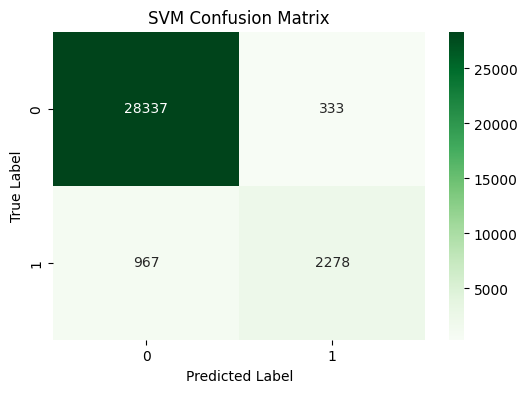

In [17]:
# ===== Support Vector Machine Full Pipeline (TF–IDF + Training + Evaluation) =====

# --- Train SVM ---
svm = LinearSVC(C=1.0)   # You can tune C later
svm.fit(X_train_tfidf, y_train)

# --- Predictions ---
y_pred_svm = svm.predict(X_test_tfidf)

# For ROC-AUC, we use decision_function since LinearSVC has no predict_proba
y_dec_svm = svm.decision_function(X_test_tfidf)

# --- Evaluation ---
print("SVM F1:", f1_score(y_test, y_pred_svm))
print("SVM ROC-AUC:", roc_auc_score(y_test, y_dec_svm))
print(classification_report(y_test, y_pred_svm))

# --- Confusion Matrix ---
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


<h1>📈 Comparison Bar Plot</h1>

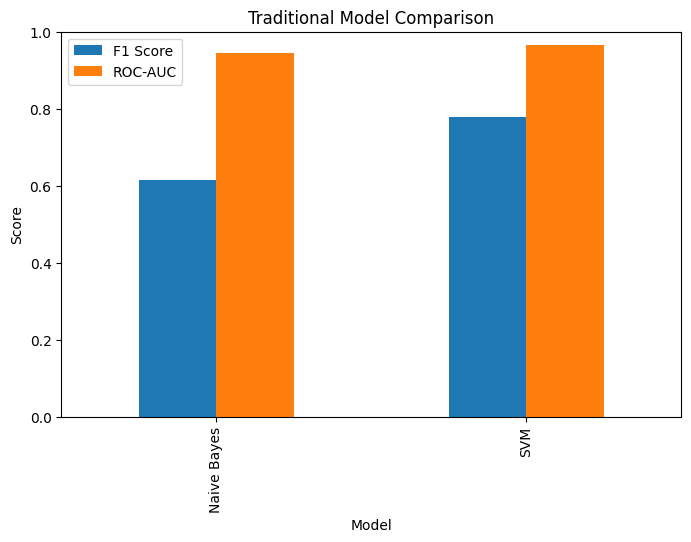

In [18]:
metrics = {
    'Model': ['Naive Bayes', 'SVM'],
    'F1 Score': [0.614, 0.778],
    'ROC-AUC': [0.945, 0.964]
}

df_metrics = pd.DataFrame(metrics)

df_metrics.plot(x='Model', y=['F1 Score', 'ROC-AUC'], kind='bar', figsize=(8,5))
plt.title("Traditional Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()


<h1>DEEP LEARNING MODELS</h1>
<h2>BiLSTM Model Block</h2>

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
798/798 ━━━━━━━━━━━━━━━━━━━━ 693s 654ms/step - accuracy: 0.9472 - loss: 0.1602 - val_accuracy: 0.9599 - val_loss: 0.1144
Epoch 2/4
798/798 ━━━━━━━━━━━━━━━━━━━━ 489s 612ms/step - accuracy: 0.9691 - loss: 0.0877 - val_accuracy: 0.9617 - val_loss: 0.1224
Epoch 3/4
798/798 ━━━━━━━━━━━━━━━━━━━━ 492s 617ms/step - accuracy: 0.9765 - loss: 0.0640 - val_accuracy: 0.9581 - val_loss: 0.1531
Epoch 4/4
798/798 ━━━━━━━━━━━━━━━━━━━━ 488s 612ms/step - accuracy: 0.9819 - loss: 0.0488 - val_accuracy: 0.9582 - val_loss: 0.1474


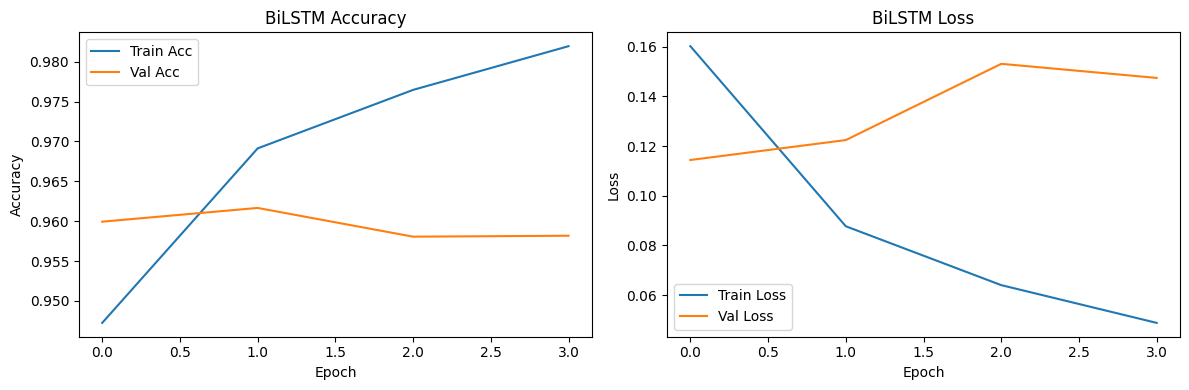

998/998 ━━━━━━━━━━━━━━━━━━━━ 62s 61ms/step
BiLSTM F1: 0.7830306825297433
BiLSTM ROC-AUC: 0.960656758835331
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     28670
           1       0.80      0.77      0.78      3245

    accuracy                           0.96     31915
   macro avg       0.88      0.87      0.88     31915
weighted avg       0.96      0.96      0.96     31915



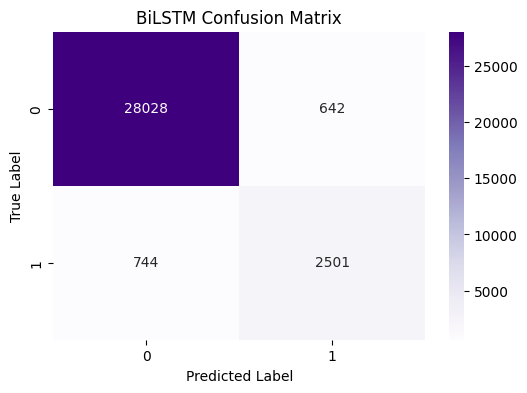

In [19]:
# ===== BiLSTM Full Pipeline: Tokenisation + Padding + Model + Training + Evaluation =====

# --- 1. Tokenisation and sequence padding for LSTM ---

max_words = 30000     # size of vocabulary (most frequent words)
max_len   = 150       # maximum sequence length (in tokens)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad / truncate sequences to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# --- 2. Define BiLSTM model architecture ---

embedding_dim = 128   # size of word embedding vectors

model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),   # 64 LSTM units in each direction
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # sigmoid for binary classification
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

# --- 3. Train the BiLSTM model ---

batch_size = 128
epochs     = 4   # can increase if you have time/GPU

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# --- 4. Plot training/validation accuracy and loss (for the report) ---

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
plt.title('BiLSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('BiLSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- 5. Evaluate on test set (F1 + ROC-AUC + report + confusion matrix) ---

# Predict probabilities, then threshold at 0.5
y_prob_lstm = model_lstm.predict(X_test_pad).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

print("BiLSTM F1:", f1_score(y_test, y_pred_lstm))
print("BiLSTM ROC-AUC:", roc_auc_score(y_test, y_prob_lstm))
print(classification_report(y_test, y_pred_lstm))

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples')
plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


<h1>Deep Model 2: Text CNN</h1>

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 216s 629ms/step - accuracy: 0.9023 - loss: 0.3025 - val_accuracy: 0.9300 - val_loss: 0.1967
Epoch 2/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 102s 680ms/step - accuracy: 0.9525 - loss: 0.1340 - val_accuracy: 0.9513 - val_loss: 0.1477
Epoch 3/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 469ms/step - accuracy: 0.9752 - loss: 0.0745 - val_accuracy: 0.9538 - val_loss: 0.1542
Epoch 4/4
150/150 ━━━━━━━━━━━━━━━━━━━━ 86s 569ms/step - accuracy: 0.9849 - loss: 0.0458 - val_accuracy: 0.9529 - val_loss: 0.1762


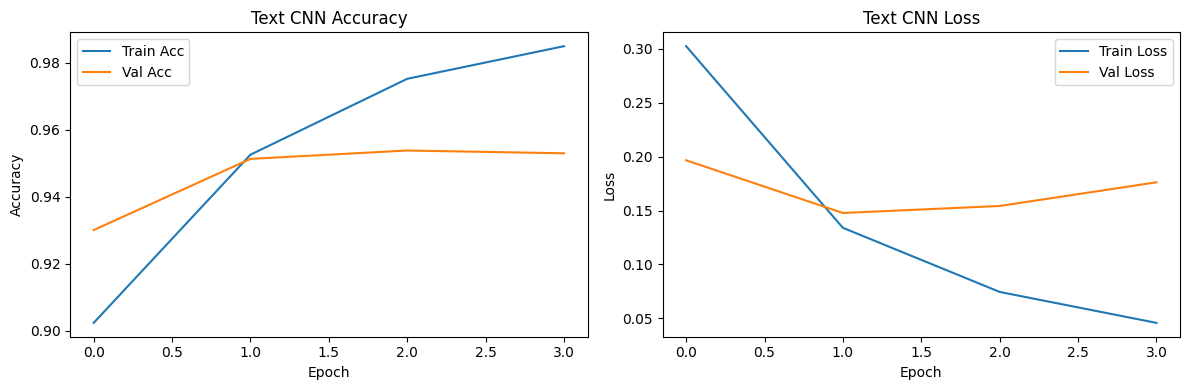

188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step
Text CNN F1: 0.7210884353741497
Text CNN ROC-AUC: 0.9418164178518305
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5396
           1       0.74      0.70      0.72       604

    accuracy                           0.95      6000
   macro avg       0.85      0.84      0.85      6000
weighted avg       0.94      0.95      0.94      6000



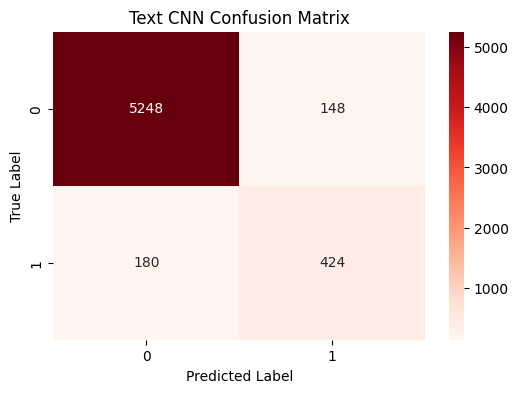

In [24]:
# ===== Text CNN for Toxic Comment Classification (Deep Model 2) =====

# --- 1. Tokenisation and padding  ---

max_words = 30000
max_len   = 150

tokenizer_cnn = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_cnn.fit_on_texts(X_train)

X_train_seq = tokenizer_cnn.texts_to_sequences(X_train)
X_test_seq  = tokenizer_cnn.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# --- 2. Define Text CNN architecture ---

embedding_dim = 128

model_cnn = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # binary output
])

model_cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_cnn.summary()

# --- 3. Train the CNN ---

batch_size = 128
epochs     = 4   # adjust if training is very fast/slow

history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# --- 4. Plot training/validation accuracy and loss ---

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.title('Text CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('Text CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- 5. Evaluate on test set (F1 + ROC-AUC + report + confusion matrix) ---

y_prob_cnn = model_cnn.predict(X_test_pad).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

print("Text CNN F1:", f1_score(y_test, y_pred_cnn))
print("Text CNN ROC-AUC:", roc_auc_score(y_test, y_prob_cnn))
print(classification_report(y_test, y_pred_cnn))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds')
plt.title("Text CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


<h1>Model Comparison</h1>

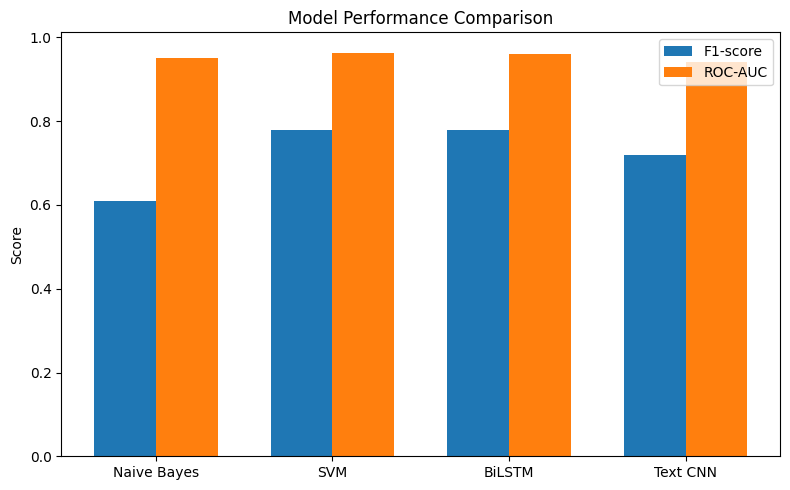

In [28]:
# Model names
models = ['Naive Bayes', 'SVM', 'BiLSTM', 'Text CNN']

# My actual results
f1_scores = [0.61, 0.78, 0.78, 0.72]
roc_auc_scores = [0.95, 0.964, 0.961, 0.942]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, f1_scores, width, label='F1-score')
plt.bar(x + width/2, roc_auc_scores, width, label='ROC-AUC')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
